# 39 — Bin-wise Adaptive Unfolding (`unfold_binned`)

This notebook demonstrates the **bin-wise adaptive** unfolding method.
For each of the 60 energy bins, the best-performing method is selected
from a pre-computed benchmark lookup table, and the final spectrum is
assembled by picking the winning value at every bin.

This approach exploits the empirical observation that different unfolding
methods excel in different energy regions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL

## 1. Set up the detector

In [2]:
detector = Detector(pd.DataFrame(RF_LANL))
print(f"Detectors: {detector.detector_names}")
print(f"Energy bins: {detector.n_energy_bins}")

Detectors: ['3in', '4in', '5in', '6in', '8in', '9in', '12in', '18in', '9inPb', '12inPb', '18inPb']
Energy bins: 60


## 2. Create  readings

In [3]:
reference_spectrum = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f'Detector grid: {detector.n_energy_bins} bins, '
      f'{detector.E_MeV[0]:.1e} – {detector.E_MeV[-1]:.1f} MeV')
print(f'Reference CSV: {len(reference_spectrum)} rows')


readings = detector.get_effective_readings_for_spectra(
    reference_spectrum[['E_MeV', 't4-14-s.txt_1']]
)

# Interpolate the reference spectrum onto the detector grid for plotting
spectrum_true = np.interp(detector.E_MeV, reference_spectrum['E_MeV'].values,
                           reference_spectrum['t4-14-s.txt_1'].values)

print('Sample readings:')
for k, v in list(readings.items())[:12]:
    print(f'  {k:6s}: {v:.2f}')

Detector grid: 60 bins, 1.0e-09 – 631.0 MeV
Reference CSV: 61 rows
Sample readings:
  3in   : 1.34
  4in   : 1.77
  5in   : 1.84
  6in   : 1.81
  8in   : 1.09
  9in   : 0.76
  12in  : 0.28
  18in  : 0.03
  9inPb : 0.94
  12inPb: 0.34
  18inPb: 0.06


## 3. Run bin-wise unfolding

In [4]:
result = detector.unfold_binned(
    readings,
    timeout_per_method=15.0,
)

print(f"Method: {result['method']}")
print(f"Successful methods: {len(result['successful_methods'])}")
print(f"Candidate methods: {len(result['candidate_methods'])}")
print(f"Residual norm: {result['residual_norm']:.6f}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [s, z]


Method: binned
Successful methods: 44
Candidate methods: 51
Residual norm: 0.149396


## 4. Plot the result

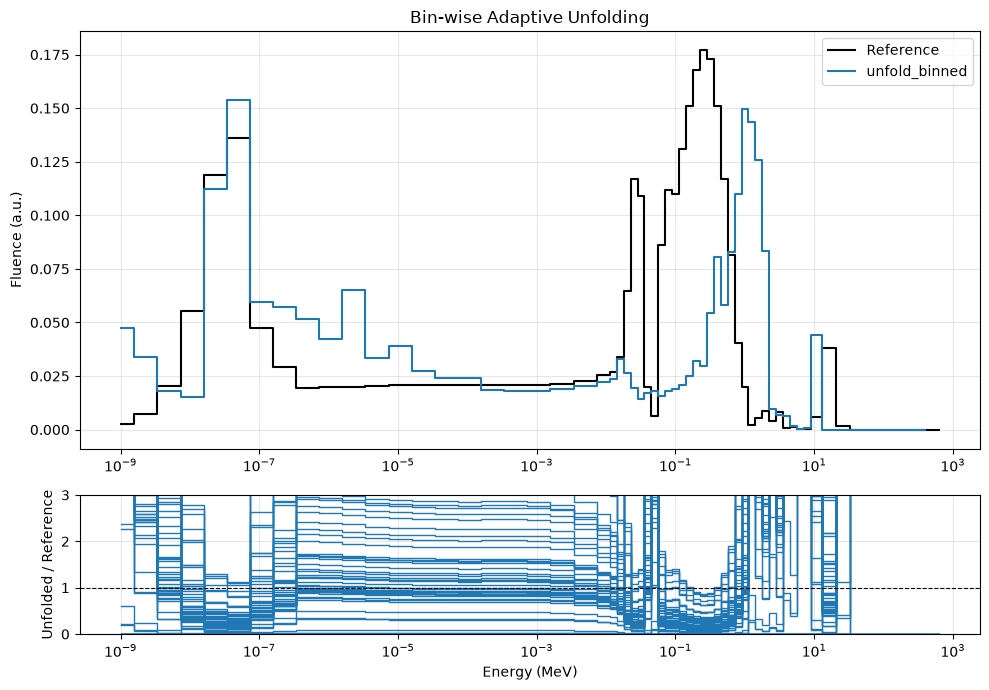

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={"height_ratios": [3, 1]})
ref= reference_spectrum[['t4-14-s.txt_1']]
E = reference_spectrum[['E_MeV']]
# Spectrum
ax = axes[0]
ax.step(E, ref, where="mid", label="Reference", color="black", linewidth=1.5)
ax.step(E[:60], result["spectrum"], where="mid", label="unfold_binned", color="tab:blue", linewidth=1.5)
ax.set_xscale("log")
ax.set_yscale("linear")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Bin-wise Adaptive Unfolding")
ax.legend()
ax.grid(True, alpha=0.3)

# Residuals
ax = axes[1]
ratio = result["spectrum"] / (ref.values + 1e-30)
ax.step(E, ratio, where="mid", color="tab:blue", linewidth=1)
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xscale("log")
ax.set_ylabel("Unfolded / Reference")
ax.set_xlabel("Energy (MeV)")
ax.set_ylim(0, 3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Visualize the method map

The `method_map` shows which method was selected for each bin.

Methods used per bin:
  mlem_odl: 16 bins
  lmfit_ic: 12 bins
  bayes: 7 bins
  genetic: 5 bins
  hybrid_gmres: 4 bins
  parametric_combined: 3 bins
  ferdor: 3 bins
  amaxed_regularization: 2 bins
  bayesian_parametric: 2 bins
  doroshenko: 2 bins
  bunkiut: 1 bins
  interpret: 1 bins
  statreg: 1 bins
  odl_pdhg: 1 bins


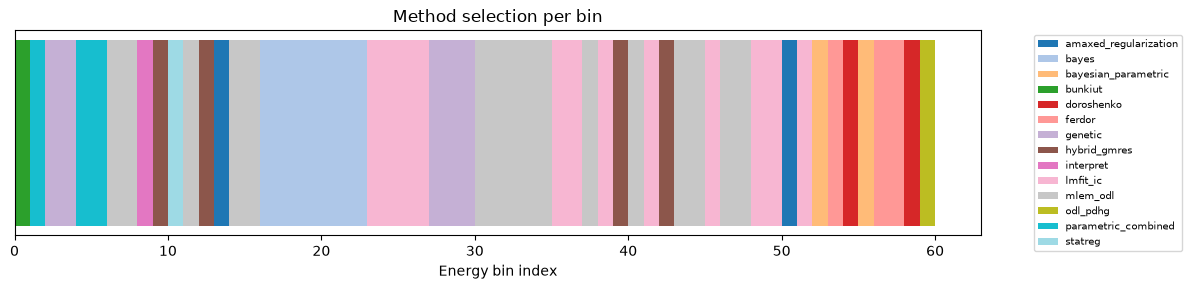

In [6]:
cands = result["candidate_methods"]
method_names = [cands[i] if i >= 0 else "?" for i in result["method_map"]]

# Count unique methods used
from collections import Counter
counts = Counter(method_names)
print("Methods used per bin:")
for name, n in counts.most_common():
    print(f"  {name}: {n} bins")

# Plot
fig, ax = plt.subplots(figsize=(12, 3))
unique_methods = sorted(set(method_names))
cmap = plt.get_cmap("tab20", len(unique_methods))
for i, m in enumerate(unique_methods):
    bins = [b for b, name in enumerate(method_names) if name == m]
    ax.barh(0, 1, left=bins[0], color=cmap(i), label=m, height=1)
    # Fix: plot each bin individually for non-contiguous ranges
    for b in bins:
        ax.barh(0, 1, left=b, color=cmap(i), height=1)

ax.set_xlabel("Energy bin index")
ax.set_yticks([])
ax.set_title("Method selection per bin")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

## 6. Compare with other methods

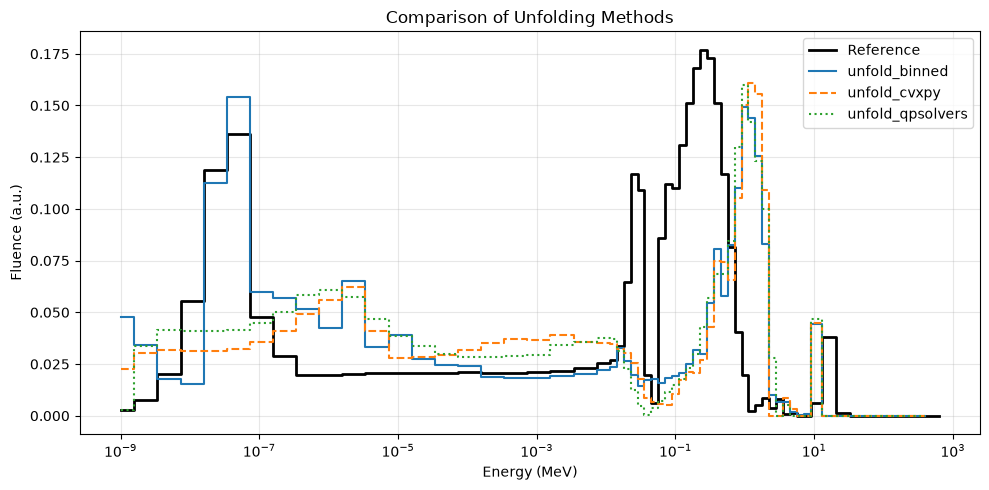

In [7]:
result_cvxpy = detector.unfold_cvxpy(readings, regularization=1e-4, norm=2)
result_qpsolvers = detector.unfold_qpsolvers(readings, regularization=1e-6, norm=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.step(E, ref, where="mid", label="Reference", color="black", linewidth=2)
ax.step(E[:60], result["spectrum"], where="mid", label="unfold_binned", linewidth=1.5)
ax.step(E[:60], result_cvxpy["spectrum"], where="mid", label="unfold_cvxpy", linewidth=1.5, linestyle="--")
ax.step(E[:60], result_qpsolvers["spectrum"], where="mid", label="unfold_qpsolvers", linewidth=1.5, linestyle=":")
ax.set_xscale("log")
ax.set_yscale("linear")
ax.set_ylabel("Fluence (a.u.)")
ax.set_xlabel("Energy (MeV)")
ax.set_title("Comparison of Unfolding Methods")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Compute quality metrics

In [8]:
from bssunfold.utils.comparison import compare_spectra

metrics_binned = compare_spectra(ref[:60], result["spectrum"], energy=E[:60])
metrics_cvxpy = compare_spectra(ref[:60], result_cvxpy["spectrum"], energy=E[:60])
metrics_qp = compare_spectra(ref[:60], result_qpsolvers["spectrum"], energy=E[:60])

print(f"{'Metric':<30} {'binned':>12} {'cvxpy':>12} {'qpsolvers':>12}")
print("-" * 66)
for key in ["cosine_similarity", "r2_score", "rmse", "wasserstein_dist", "kl_divergence"]:
    if key == "rmse":
        k = "root_mean_squared_error"
    else:
        k = key
    v1 = metrics_binned.get(k, np.nan)
    v2 = metrics_cvxpy.get(k, np.nan)
    v3 = metrics_qp.get(k, np.nan)
    print(f"{key:<30} {v1:>12.6f} {v2:>12.6f} {v3:>12.6f}")

Metric                               binned        cvxpy    qpsolvers
------------------------------------------------------------------
cosine_similarity                       nan          nan          nan
r2_score                         -92.888398   -90.908344   -89.426187
rmse                               0.065762     0.065064     0.064538
wasserstein_dist                        nan          nan          nan
kl_divergence                    296.494228   214.448152   373.795355


/home/chizhov/python/bssunfold/src/bssunfold/utils/comparison.py:979: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(pearsonr(leth1, leth2)[0])
/home/chizhov/python/bssunfold/src/bssunfold/utils/comparison.py:979: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(pearsonr(leth1, leth2)[0])


## 8. Custom lookup table

You can build your own lookup from a subset of methods or a custom
benchmark dataset.

In [9]:
from bssunfold.core.unfold_binned import build_bin_lookup, save_bin_lookup

# Build with only top-3 methods per bin
# (requires gridsearch NPZ data in paper_v2/gridsearch/results/spectra/)
# lookup = build_bin_lookup(
#     spectra_dir="paper_v2/gridsearch/results/spectra/mc",
#     references_csv="tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv",
#     top_k=3,
# )
# save_bin_lookup(lookup, "/tmp/my_bin_lookup.json")

# Use a custom lookup
# result = detector.unfold_binned(readings, lookup_path="/tmp/my_bin_lookup.json")

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
